# Data Analysis Graph

This notebook implements a LangGraph workflow for data analysis using AI agents.

## Setup and Configuration

In [192]:
# Import required libraries
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# Import settings
from src.config import settings

print(f"Application: {settings.app_name}")
print(f"Version: {settings.app_version}")
print(f"Default LLM Model: {settings.default_llm_model}")
print(f"Temperature: {settings.default_llm_temperature}")


Application: Data Agent LangGraph
Version: 0.1.0
Default LLM Model: gpt-4o
Temperature: 0.7


## Import Dependencies

In [193]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
import pandas as pd
import numpy as np
from typing import Any, Optional, List

## State definition

In [ ]:
# create custom reducers

from typing import Dict


def reduce_search_payload(left: Dict[str,str] | None, right: Dict[str,str] | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = {}
    if not right:
        right={}
        
    left_copy=left.copy()
    
    left_copy.update(right)
        
    return left_copy


In [ ]:
from typing import Dict


class UploadedAtPayload(TypedDict):
    from_date: str
    to_date: str

class FieldsPayload(TypedDict):
    name: str
    value: str
    
class DocFieldsPayload(TypedDict):
    doctype: str
    fields: List[FieldsPayload]
    
class SearchPayload(TypedDict):
    uploaded_at: Optional[UploadedAtPayload]
    queues: Optional[Dict[str,str]]
    others: DocFieldsPayload

class OverallState(TypedDict):
    messages: Annotated[list, add_messages]
    intent: Optional[str]
    search_attributes: Optional[list[str]]
    search_payload: Annotated[SearchPayload,reduce_search_payload]

## Init LLM

In [195]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model=settings.default_llm_model, 
    temperature=settings.default_llm_temperature,
    api_key=settings.openai_api_key
)

## Intent classification node

In [196]:
from typing import Literal
from pydantic import BaseModel, Field
from graphs.prompts.intent_classification import INTENT_CLASSIFICATION_PROMPT

class IntentClassificationOutput(BaseModel):
    intent: Literal["search", "document_accuracy", "document_counter", "document_processing_time", "others"] = Field(
        ..., 
        description="The user's intent based on the conversation."
    )    
    reasoning: str = Field(..., description="The reasoning behind the intent classification.")


def intent_classifier(state: OverallState):
    
    structured_llm = llm.with_structured_output(IntentClassificationOutput)
    
    output = structured_llm.invoke([SystemMessage(content=INTENT_CLASSIFICATION_PROMPT)] + state["messages"])
    
    print("llm_output: ", output)
    
    return {"intent": output.intent,"messages":[AIMessage(content=output.reasoning)]}

## Request user input for edge cases:

In [197]:
def user_input_clarity(state:OverallState):
    pass

## Conditional routing for intent

In [198]:
def routing_intent(state: OverallState):
    if state['intent'] in ["document_accuracy", "document_counter", "document_processing_time"]:
        return "document parameters intent"
    
    if state['intent'] == 'others':
        # human in the loop ask user to input again
        return "unclear intent"
    
    return "search intent"

## Extract search attrbutes node for search query

In [199]:
from graphs.prompts.search_attributes_extraction import SEARCH_ATTRIBUTES_EXTRACTION_PROMPT

# Pydantic model for LLM response
class AttributesExtraction(BaseModel):
    """Classification of user intent"""
    attributes: List[Literal["document_model", "queue", "date"]] = Field(
        description="The attributes that need to be extracted. Must only contain: document model, queue, or date"
    )


# Node 2: Search Node (placeholder)
def extract_search_attributes_from_query(state: OverallState) -> dict:
    """Placeholder search node - empty for now"""
        
    # Use structured output with Pydantic
    structured_llm = llm.with_structured_output(AttributesExtraction)
    
    messages = [SystemMessage(content=SEARCH_ATTRIBUTES_EXTRACTION_PROMPT)] + state['messages']
    
    result: AttributesExtraction = structured_llm.invoke(messages)
    
    print("extracted attributed result: ",result)
    
    if not result.attributes:
        print("There are no valid attributes can be extracted from your query")
    else:
        print(f"Valid extracted attributes: {', '.join(result.attributes)}")
    
    
    return {
        "search_attributes": result.attributes
    }

## Conditional routing for extracted search query 

In [200]:
def routing_extracted_search_attributes(state: OverallState):
    search_attributes=state['search_attributes']
    
    if not search_attributes:
        print("There are no valid search attributes")
        return "vague search query"
    
    return "valid search query"

## Routing processing search attributes

In [201]:
def router_processing_search_attributes(state: OverallState):
    return {}

def routing_processing_search_attributes(state: OverallState):
    
    search_attributes=state['search_attributes']
    
    if not search_attributes:
        print("complete all processing")
        return "complete processing"
    
    if "queue" in search_attributes:
        return "processing queue attribute"
    

## Processing Search Attribute Node

In [202]:
def processing_queue_search_attribute_node(state: OverallState):
    return {}

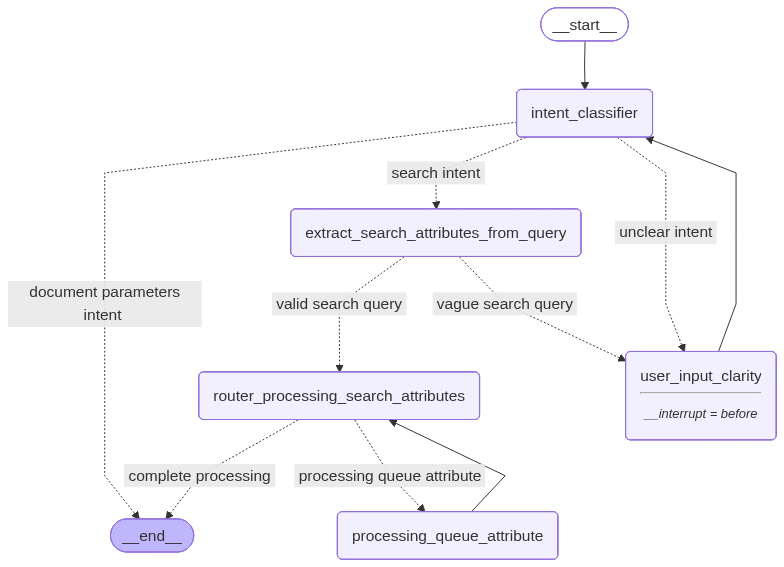

In [203]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

test_builder=StateGraph(OverallState)

test_builder.add_node("intent_classifier",intent_classifier)
test_builder.add_node("user_input_clarity",user_input_clarity)
test_builder.add_node("extract_search_attributes_from_query",extract_search_attributes_from_query)
test_builder.add_node("router_processing_search_attributes",router_processing_search_attributes)
test_builder.add_node("processing_queue_attribute",processing_queue_search_attribute_node)


test_builder.add_edge(START,"intent_classifier")
test_builder.add_conditional_edges("intent_classifier", 
                                   routing_intent, 
                                   {"unclear intent":"user_input_clarity", 
                                    "search intent":"extract_search_attributes_from_query",
                                    "document parameters intent":END}
                                   )
test_builder.add_edge("user_input_clarity","intent_classifier")
test_builder.add_conditional_edges("extract_search_attributes_from_query", 
                                   routing_extracted_search_attributes, 
                                   {"vague search query":"user_input_clarity",
                                    "valid search query":"router_processing_search_attributes"})
test_builder.add_conditional_edges("router_processing_search_attributes", 
                                   routing_processing_search_attributes, 
                                   {"processing queue attribute":"processing_queue_attribute",
                                    "complete processing":END})
test_builder.add_edge("processing_queue_attribute","router_processing_search_attributes")


# Compile
memory = MemorySaver()
graph = test_builder.compile(interrupt_before=["user_input_clarity"],checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [204]:
# graph.invoke({"messages": [HumanMessage(content="I want to search all documents from queue xyz from 1/11/2025 to now and from invoice model")]})

# graph.invoke({"messages": [HumanMessage(content="I want to know the document processing time")]})
thread = {"configurable": {"thread_id": "1"}}

graph.invoke({"messages": [HumanMessage(content="I wanna search documents")]},thread)

llm_output:  intent='search' reasoning="The user has explicitly stated their desire to search for documents, which aligns with the 'search' intent."
extracted attributed result:  attributes=[]
There are no valid attributes can be extracted from your query
There are no valid search attributes


{'messages': [HumanMessage(content='I wanna search documents', additional_kwargs={}, response_metadata={}, id='6d1e90e1-e98a-4571-88a5-dbb7b34df3c4'),
  AIMessage(content="The user has explicitly stated their desire to search for documents, which aligns with the 'search' intent.", additional_kwargs={}, response_metadata={}, id='976566a6-8e84-49a3-8057-2e1c3b027cdb')],
 'intent': 'search',
 'search_attributes': []}

In [205]:
state = graph.get_state(thread)
state

StateSnapshot(values={'messages': [HumanMessage(content='I wanna search documents', additional_kwargs={}, response_metadata={}, id='6d1e90e1-e98a-4571-88a5-dbb7b34df3c4'), AIMessage(content="The user has explicitly stated their desire to search for documents, which aligns with the 'search' intent.", additional_kwargs={}, response_metadata={}, id='976566a6-8e84-49a3-8057-2e1c3b027cdb')], 'intent': 'search', 'search_attributes': []}, next=('user_input_clarity',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0c7af0-7183-6704-8002-68c1a7c6f4f3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-22T14:25:00.071683+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0c7af0-6b8d-67e6-8001-771f905f7349'}}, tasks=(PregelTask(id='05ded1a9-46af-9301-2267-de1e13f577cd', name='user_input_clarity', path=('__pregel_pull', 'user_input_clarity'), error=None, interrupts=(), state=None, result

In [206]:
state.next

('user_input_clarity',)

In [207]:
graph.update_state(
    thread,
    {"messages":[HumanMessage(content="I want to search for all documents under queue starting with Louis")]}
)

There are no valid search attributes


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0c7af0-71f7-6b9a-8003-8305eae1e821'}}

In [208]:
graph.invoke(None,thread)

llm_output:  intent='search' reasoning="The user is requesting to search for documents with a specific criterion, namely the queue name starting with 'Louis'. This matches the 'search' intent as they are looking to find documents based on a specific filter."
extracted attributed result:  attributes=['queue']
Valid extracted attributes: queue


GraphRecursionError: Recursion limit of 25 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT